In [1]:
# ==========================================
# Standard Library
# ==========================================

from pathlib import Path
import warnings
import logging
import random

# ==========================================
# Data Processing
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Sklearn
# ==========================================

from sklearn.model_selection import GroupShuffleSplit

# ==========================================
# Notebook Settings
# ==========================================

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# ==========================================
# Project Configuration
# ==========================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"

PROCESSED_DIR = DATA_DIR / "processed"

IMAGE_DIR = RAW_DIR / "images"

CLEAN_METADATA = PROCESSED_DIR / "clean_metadata.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_INPUT_SIZE = (224,224)

print(PROJECT_ROOT)
print(CLEAN_METADATA)

c:\Users\HP\MED-AGENT
c:\Users\HP\MED-AGENT\data\processed\clean_metadata.csv


In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger("MedAgent")

In [4]:
print("="*60)

print("VERIFYING FILES")

print("="*60)

items = {
    "Metadata": CLEAN_METADATA,
    "Images": IMAGE_DIR
}

for name,path in items.items():

    if path.exists():

        print(f"✅ {name}")

    else:

        print(f"❌ {name}")

VERIFYING FILES
✅ Metadata
✅ Images


In [5]:
logger.info("Loading Clean Metadata...")

df = pd.read_csv(CLEAN_METADATA)

logger.info("Metadata Loaded Successfully.")

print(df.shape)

display(df.head())

2026-07-21 00:20:07,157 | INFO | Loading Clean Metadata...
2026-07-21 00:20:07,676 | INFO | Metadata Loaded Successfully.


(112120, 13)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Num_Diseases,Is_Normal
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143,1,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,2,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,2,0
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171,1,1
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168,1,0


In [6]:
print("="*60)

print("DATASET SUMMARY")

print("="*60)

print(f"Images           : {len(df):,}")

print(f"Patients         : {df['Patient ID'].nunique():,}")

print(f"Normal Images    : {df['Is_Normal'].sum():,}")

print(f"Disease Images   : {(df['Is_Normal']==0).sum():,}")

DATASET SUMMARY
Images           : 112,120
Patients         : 30,805
Normal Images    : 60,361
Disease Images   : 51,759


In [7]:
display(df[["Image Index","Finding Labels"]].head(15))

,Image Index,Finding Labels
0,00000001_000.png,Cardiomegaly
1,00000001_001.png,Cardiomegaly|Emphysema
2,00000001_002.png,Cardiomegaly|Effusion
3,00000002_000.png,No Finding
4,00000003_001.png,Hernia
5,00000003_002.png,Hernia
6,00000003_003.png,Hernia|Infiltration
7,00000003_004.png,Hernia
8,00000003_005.png,Hernia
9,00000003_006.png,Hernia


In [8]:
from sklearn.preprocessing import MultiLabelBinarizer

In [9]:
# ==========================================
# Convert Labels to List
# ==========================================

df["Disease_List"] = df["Finding Labels"].apply(
    lambda x: x.split("|")
)

display(df[["Finding Labels", "Disease_List"]].head())

,Finding Labels,Disease_List
0,Cardiomegaly,[Cardiomegaly]
1,Cardiomegaly|Emphysema,"[Cardiomegaly, Emphysema]"
2,Cardiomegaly|Effusion,"[Cardiomegaly, Effusion]"
3,No Finding,[No Finding]
4,Hernia,[Hernia]


In [10]:
# ==========================================
# Multi Label Encoding
# ==========================================

mlb = MultiLabelBinarizer()

encoded_labels = mlb.fit_transform(df["Disease_List"])

print("Number of Classes:", len(mlb.classes_))

print("\nDisease Classes:")

print(mlb.classes_)

Number of Classes: 15

Disease Classes:
['Atelectasis' 'Cardiomegaly' 'Consolidation' 'Edema' 'Effusion'
 'Emphysema' 'Fibrosis' 'Hernia' 'Infiltration' 'Mass' 'No Finding'
 'Nodule' 'Pleural_Thickening' 'Pneumonia' 'Pneumothorax']


In [11]:
encoded_df = pd.DataFrame(
    encoded_labels,
    columns=mlb.classes_,
    index=df.index
)

display(encoded_df.head())

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [12]:
df = pd.concat(
    [df, encoded_df],
    axis=1
)

print(df.shape)

display(df.head())

(112120, 29)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Num_Diseases,Is_Normal,Disease_List,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143,1,0,[Cardiomegaly],0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,2,0,"[Cardiomegaly, Emphysema]",0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,2,0,"[Cardiomegaly, Effusion]",0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171,1,1,[No Finding],0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168,1,0,[Hernia],0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [13]:
sample = df.sample(5)

display(
    sample[
        [
            "Finding Labels",
            *mlb.classes_
        ]
    ]
)

,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
49368,Atelectasis|Effusion|Pleural_Thickening,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
77286,No Finding,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
102062,No Finding,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
85618,No Finding,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
63877,Cardiomegaly,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
import json

class_file = PROCESSED_DIR / "disease_classes.json"

with open(class_file, "w") as f:
    json.dump(
        list(mlb.classes_),
        f,
        indent=4
    )

print("Disease classes saved.")

print(class_file)

Disease classes saved.
c:\Users\HP\MED-AGENT\data\processed\disease_classes.json


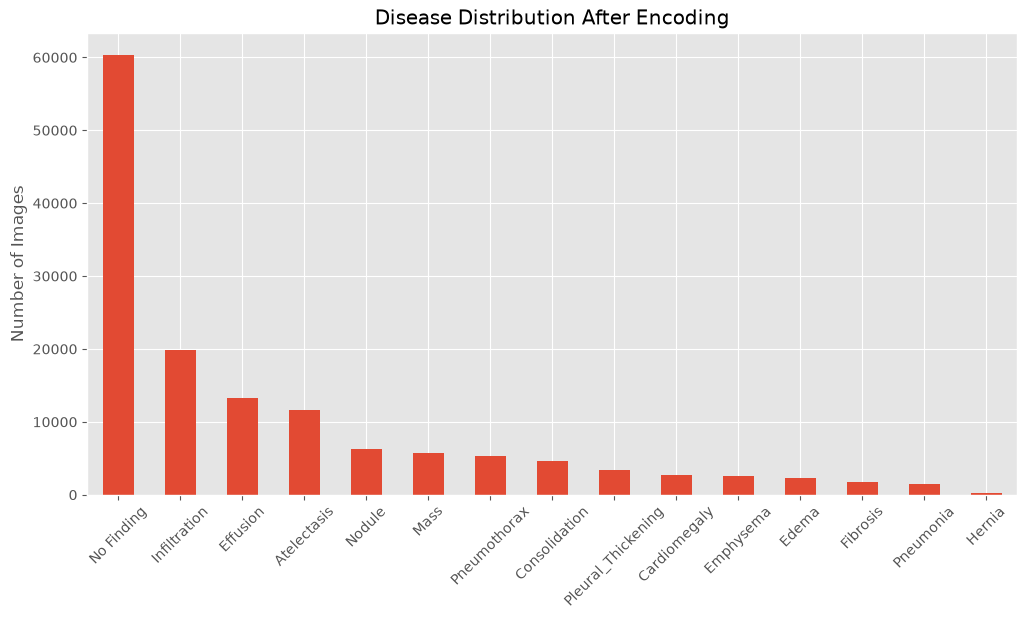

In [15]:
disease_counts = encoded_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

disease_counts.plot(kind="bar")

plt.title("Disease Distribution After Encoding")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [16]:
# ==========================================
# Patient Statistics
# ==========================================

print("=" * 60)
print("PATIENT INFORMATION")
print("=" * 60)

num_patients = df["Patient ID"].nunique()

print(f"Total Images   : {len(df):,}")
print(f"Total Patients : {num_patients:,}")

avg_images = len(df) / num_patients

print(f"Average Images per Patient : {avg_images:.2f}")

PATIENT INFORMATION
Total Images   : 112,120
Total Patients : 30,805
Average Images per Patient : 3.64


In [17]:
# ==========================================
# Train / Temp Split
# ==========================================

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(
        df,
        groups=df["Patient ID"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)

temp_df = df.iloc[temp_idx].reset_index(drop=True)

print("Train Shape :", train_df.shape)

print("Temp Shape  :", temp_df.shape)

Train Shape : (78566, 29)
Temp Shape  : (33554, 29)


In [18]:
# ==========================================
# Validation / Test Split
# ==========================================

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Validation Shape :", val_df.shape)

print("Testing Shape    :", test_df.shape)

Validation Shape : (16106, 29)
Testing Shape    : (17448, 29)


In [19]:
# ==========================================
# Dataset Sizes
# ==========================================

total = len(df)

print("=" * 60)

print("DATASET SPLIT")

print("=" * 60)

print(f"Training   : {len(train_df):6} ({100*len(train_df)/total:.2f}%)")

print(f"Validation : {len(val_df):6} ({100*len(val_df)/total:.2f}%)")

print(f"Testing    : {len(test_df):6} ({100*len(test_df)/total:.2f}%)")

DATASET SPLIT
Training   :  78566 (70.07%)
Validation :  16106 (14.36%)
Testing    :  17448 (15.56%)


In [20]:
# ==========================================
# Patient Leakage Check
# ==========================================

train_patients = set(train_df["Patient ID"])

val_patients = set(val_df["Patient ID"])

test_patients = set(test_df["Patient ID"])

print("Train ∩ Validation :", len(train_patients & val_patients))

print("Train ∩ Test       :", len(train_patients & test_patients))

print("Validation ∩ Test  :", len(val_patients & test_patients))

Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0


In [21]:
# ==========================================
# Compare Disease Distribution
# ==========================================

disease_columns = list(mlb.classes_)

split_distribution = pd.DataFrame({
    "Train": train_df[disease_columns].sum(),
    "Validation": val_df[disease_columns].sum(),
    "Test": test_df[disease_columns].sum()
})

display(split_distribution)

,Train,Validation,Test
Atelectasis,8190,1611,1758
Cardiomegaly,1891,389,496
Consolidation,3228,668,771
Edema,1630,339,334
Effusion,9438,1841,2038
Emphysema,1666,378,472
Fibrosis,1156,253,277
Hernia,158,35,34
Infiltration,13868,2933,3093
Mass,4260,762,760


In [22]:
# ==========================================
# Save Dataset Splits
# ==========================================

train_df.to_csv(PROCESSED_DIR / "train_metadata.csv", index=False)

val_df.to_csv(PROCESSED_DIR / "validation_metadata.csv", index=False)

test_df.to_csv(PROCESSED_DIR / "test_metadata.csv", index=False)

print("✅ Dataset splits saved successfully.")

✅ Dataset splits saved successfully.


In [23]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_df), len(val_df), len(test_df)],
    "Patients": [
        train_df["Patient ID"].nunique(),
        val_df["Patient ID"].nunique(),
        test_df["Patient ID"].nunique()
    ]
})

display(summary)

FINAL DATASET SUMMARY


,Split,Images,Patients
0,Train,78566,21563
1,Validation,16106,4621
2,Test,17448,4621


In [24]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [25]:
# ==========================================
# PyTorch
# ==========================================

import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================
# Torchvision
# ==========================================

from torchvision import transforms

# ==========================================
# PIL
# ==========================================

from PIL import Image

In [26]:
IMAGE_SIZE = 224

In [27]:
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [28]:
val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [29]:
test_transform = val_transform

In [30]:
print(train_transform)

print()

print(val_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485], std=[0.229])
)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485], std=[0.229])
)


In [31]:
print("="*60)

print("TRAIN TRANSFORM")

print("="*60)

print(train_transform)

TRAIN TRANSFORM
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485], std=[0.229])
)


In [32]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.13.0+cpu
0.28.0+cpu


In [33]:
# ==========================================
# Build Image Lookup Dictionary
# ==========================================

image_lookup = {}

image_folders = sorted(IMAGE_DIR.glob("images_*"))

for folder in image_folders:

    actual_folder = folder / "images"

    for img_path in actual_folder.glob("*.png"):

        image_lookup[img_path.name] = img_path

print(f"Total Images Indexed: {len(image_lookup):,}")

Total Images Indexed: 112,120


In [34]:
sample_name = train_df.iloc[0]["Image Index"]

print(sample_name)

print(image_lookup[sample_name])

00000001_000.png
c:\Users\HP\MED-AGENT\data\raw\images\images_001\images\00000001_000.png


In [35]:
label_columns = list(mlb.classes_)

print(label_columns)

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [36]:
class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, image_lookup, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.image_lookup = image_lookup

        self.transform = transform

        self.label_columns = label_columns


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_name = row["Image Index"]

        image_path = self.image_lookup[image_name]

        image = Image.open(image_path).convert("L")

        if self.transform:

            image = self.transform(image)

        labels = torch.tensor(

            row[self.label_columns].values.astype(np.float32)

        )

        return image, labels

In [37]:
train_dataset = ChestXrayDataset(

    train_df,

    image_lookup,

    train_transform

)

val_dataset = ChestXrayDataset(

    val_df,

    image_lookup,

    val_transform

)

test_dataset = ChestXrayDataset(

    test_df,

    image_lookup,

    test_transform

)

In [38]:
print("Training Images :", len(train_dataset))

print("Validation Images :", len(val_dataset))

print("Testing Images :", len(test_dataset))

Training Images : 78566
Validation Images : 16106
Testing Images : 17448


In [39]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)

print("Label Shape :", label.shape)

print(label)

Image Shape : torch.Size([1, 224, 224])
Label Shape : torch.Size([15])
tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [40]:
# ==========================================
# Class Frequencies
# ==========================================

class_counts = train_df[label_columns].sum()

class_counts = class_counts.sort_values(ascending=False)

display(class_counts)

No Finding            42210
Infiltration          13868
Effusion               9438
Atelectasis            8190
Nodule                 4432
Mass                   4260
Pneumothorax           3770
Consolidation          3228
Pleural_Thickening     2379
Cardiomegaly           1891
Emphysema              1666
Edema                  1630
Fibrosis               1156
Pneumonia               995
Hernia                  158
dtype: int64

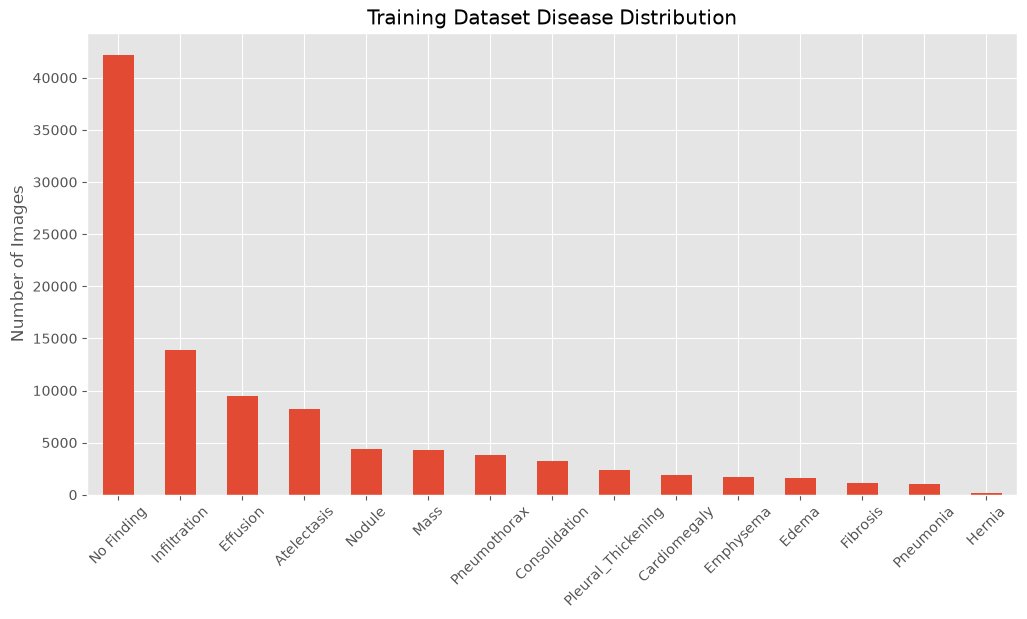

In [41]:
plt.figure(figsize=(12,6))

class_counts.plot(kind="bar")

plt.title("Training Dataset Disease Distribution")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [42]:
# ==========================================
# Positive Class Weights
# ==========================================

num_samples = len(train_df)

positive_counts = train_df[label_columns].sum()

negative_counts = num_samples - positive_counts

pos_weights = negative_counts / positive_counts

pos_weights = torch.tensor(
    pos_weights.values,
    dtype=torch.float32
)

print(pos_weights)

tensor([  8.5929,  40.5473,  23.3389,  47.2000,   7.3244,  46.1585,  66.9637,
        496.2532,   4.6653,  17.4427,   0.8613,  16.7270,  32.0248,  77.9608,
         19.8398])


In [43]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weights
)

print("Loss Function Created")

Loss Function Created


In [44]:
from torch.utils.data import WeightedRandomSampler

In [45]:
# ==========================================
# Sample Weights
# ==========================================

sample_weights = []

for _, row in train_df.iterrows():

    labels = row[label_columns].values

    positive_indices = np.where(labels == 1)[0]

    if len(positive_indices) == 0:

        weight = 1.0

    else:

        weight = pos_weights[positive_indices].mean().item()

    sample_weights.append(weight)

sample_weights = torch.DoubleTensor(sample_weights)

print(sample_weights.shape)

torch.Size([78566])


In [46]:
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Weighted Sampler Ready")

Weighted Sampler Ready


In [47]:
BATCH_SIZE = 32

In [48]:
# ==========================================
# Train DataLoader
# ==========================================

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=0,      # Windows/Jupyter compatible
    pin_memory=False,   # No GPU, so disable
    persistent_workers=False
)

print("✅ Train DataLoader Created")

✅ Train DataLoader Created


In [49]:
# ==========================================
# Validation DataLoader
# ==========================================

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False
)

print("✅ Validation DataLoader Created")

✅ Validation DataLoader Created


In [50]:
# ==========================================
# Test DataLoader
# ==========================================

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False
)

print("✅ Test DataLoader Created")

✅ Test DataLoader Created


In [51]:
import time

print("=" * 60)
print("Testing Dataset")
print("=" * 60)

start = time.time()

image, label = train_dataset[0]

end = time.time()

print(f"Time Taken : {end-start:.3f} seconds")

print("Image Shape :", image.shape)

print("Label Shape :", label.shape)

Testing Dataset
Time Taken : 0.011 seconds
Image Shape : torch.Size([1, 224, 224])
Label Shape : torch.Size([15])


In [52]:
import time

print("=" * 60)
print("Testing DataLoader")
print("=" * 60)

start = time.time()

images, labels = next(iter(train_loader))

end = time.time()

print(f"Time Taken : {end-start:.3f} seconds")

print("Images Shape :", images.shape)

print("Labels Shape :", labels.shape)

Testing DataLoader
Time Taken : 0.719 seconds
Images Shape : torch.Size([32, 1, 224, 224])
Labels Shape : torch.Size([32, 15])


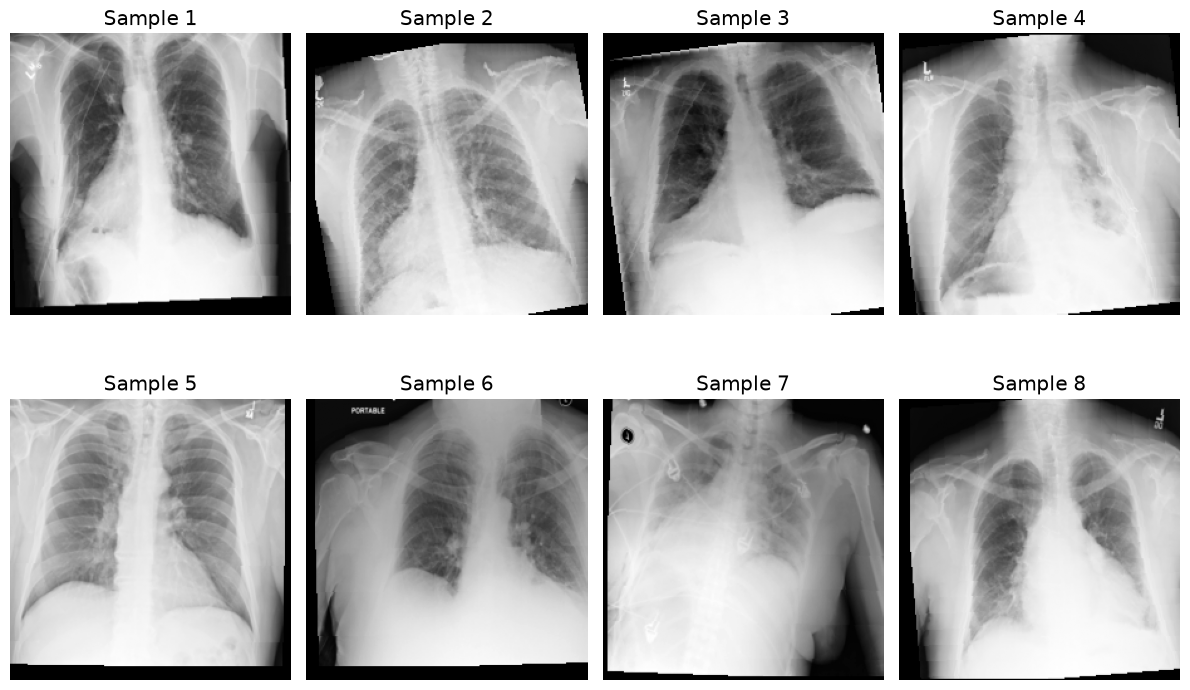

In [53]:
# ==========================================
# Visualize Batch
# ==========================================

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 8))

for i, ax in enumerate(axes.flat):

    img = images[i].squeeze().numpy()

    ax.imshow(img, cmap="gray")

    ax.set_title(f"Sample {i+1}")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [54]:
print("=" * 60)
print("Batch Verification")
print("=" * 60)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

print()

print("Number of Diseases :", len(label_columns))
print("Disease Names :")

for disease in label_columns:
    print("-", disease)

Batch Verification
Image Batch Shape : torch.Size([32, 1, 224, 224])
Label Batch Shape : torch.Size([32, 15])

Number of Diseases : 15
Disease Names :
- Atelectasis
- Cardiomegaly
- Consolidation
- Edema
- Effusion
- Emphysema
- Fibrosis
- Hernia
- Infiltration
- Mass
- No Finding
- Nodule
- Pleural_Thickening
- Pneumonia
- Pneumothorax


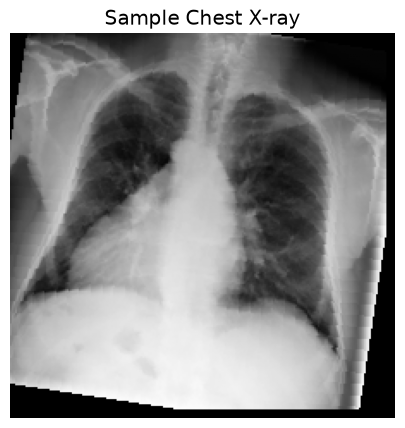

Positive Diseases:

✔ Cardiomegaly


In [55]:
sample_image, sample_label = train_dataset[0]

plt.figure(figsize=(5,5))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.axis("off")
plt.title("Sample Chest X-ray")
plt.show()

print("Positive Diseases:\n")

for disease, value in zip(label_columns, sample_label):

    if value == 1:

        print("✔", disease)

In [56]:
summary = {
    "Training Images": len(train_dataset),
    "Validation Images": len(val_dataset),
    "Testing Images": len(test_dataset),
    "Total Diseases": len(label_columns),
    "Batch Size": BATCH_SIZE
}

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

for k, v in summary.items():
    print(f"{k:25}: {v}")

DATASET SUMMARY
Training Images          : 78566
Validation Images        : 16106
Testing Images           : 17448
Total Diseases           : 15
Batch Size               : 32


In [57]:
import json

config = {
    "image_size": 224,
    "batch_size": BATCH_SIZE,
    "num_classes": len(label_columns),
    "disease_classes": label_columns
}

with open(PROCESSED_DIR / "dataset_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ Dataset configuration saved.")

✅ Dataset configuration saved.


In [58]:
print("=" * 60)
print("NOTEBOOK 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Completed Tasks:")
print("✔ Data Cleaning")
print("✔ Multi-label Encoding")
print("✔ Patient-wise Split")
print("✔ Image Preprocessing")
print("✔ Image Lookup")
print("✔ Custom Dataset")
print("✔ Class Weights")
print("✔ Weighted Sampler")
print("✔ DataLoader")
print("✔ Batch Verification")

print("\nReady for Notebook 3: Model Development 🚀")

NOTEBOOK 2 COMPLETED SUCCESSFULLY
Completed Tasks:
✔ Data Cleaning
✔ Multi-label Encoding
✔ Patient-wise Split
✔ Image Preprocessing
✔ Image Lookup
✔ Custom Dataset
✔ Class Weights
✔ Weighted Sampler
✔ DataLoader
✔ Batch Verification

Ready for Notebook 3: Model Development 🚀


In [59]:
images, labels = next(iter(train_loader))